[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/02_unidad/02_01_regresion.ipynb)


# Regresión polinomial con datos simulados (Ridge + validación cruzada)

**Asignatura:** Fundamentos de aprendizaje automático / analítica  

## Objetivo

- Construir un problema de regresión con **una variable numérica** $x$ y una respuesta continua $y$ generadas por una **ley conocida** (polinomio + ruido), para que el aprendizaje sea **reproducible y didáctico**.
- Entrenar un **pipeline** `PolynomialFeatures` → `StandardScaler` → **Ridge**, calibrar **grado** y **fuerza de regularización** solo con **validación cruzada sobre entrenamiento**.
- **Evaluar una sola vez** el rendimiento en **test** y comparar con un **baseline** simple.
- Revisar de forma explícita **supuestos** habituales del modelo lineal en las *features* (residuos y normalidad aproximada).

> En otra actividad usaremos un dataset **real vía OpenML** para contrastar este mismo flujo con datos menos "limpios".

## ¿Qué son las potencias de $x$?

La **regresión polinomial** no es un algoritmo distinto al lineal: es una regresión **lineal** sobre **nuevas columnas** derivadas de $x$: $x, x^2, x^3, \ldots, x^d$. El modelo busca coeficientes que combinan esas columnas para aproximar $y$. Al subir el **grado** $d$, la curva puede volverse más flexible; también es más fácil **sobreajustar** el ruido de entrenamiento.

---
## 1. Generación de datos y exploración breve

Fijamos semillas para que cualquier persona obtenga la **misma** muestra. La relación verdadera será cuadrática con ruido gaussiano (tú puedes cambiar coeficientes en clase para experimentar).

Además, desde este primer bloque mostramos de forma explícita un **dataset polinomial** de ejemplo (`x`, `x^2`, `x^3`) para visualizar que el modelo no trabaja solo con una columna lineal.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

n = 400
x = rng.uniform(-2.0, 2.0, size=n)

# Ley verdadera: y = beta0 + beta1*x + beta2*x^2 + ruido
beta0, beta1, beta2 = 1.0, 2.0, -1.2
noise_sd = 0.5
y = beta0 + beta1 * x + beta2 * (x ** 2) + rng.normal(0.0, noise_sd, size=n)

df = pd.DataFrame({"x": x, "y": y})

# Dataset sintético polinomial explícito (grado 3) + y
poly_preview = PolynomialFeatures(degree=3, include_bias=False)
X_preview = poly_preview.fit_transform(df[["x"]])
df_sintetico_g3 = pd.DataFrame(X_preview, columns=["x", "x^2", "x^3"])
df_sintetico_g3["y"] = df["y"].values

print("Dataset sintético (grado 3) + y")
print("Forma:", df_sintetico_g3.shape)
display(df_sintetico_g3.head(50))

Dataset sintético (grado 3) + y
Forma: (400, 4)


,x,x^2,x^3,y
0,1.095824,1.200831,1.315899,1.970470
1,-0.244486,0.059774,-0.014614,0.701393
2,1.434392,2.057479,2.951231,1.537945
3,0.789472,0.623266,0.492051,1.124642
4,-1.623291,2.635072,-4.277488,-6.563720
5,1.902489,3.619466,6.885996,0.488796
6,1.044559,1.091103,1.139721,1.543906
7,1.144257,1.309325,1.498204,1.947018
8,-1.487545,2.212792,-3.291628,-4.279464
9,-0.198456,0.039385,-0.007816,0.624946


---
## 2. Partición entrenamiento / prueba

**¿Por qué no evaluar solo en train?** Si ajustamos y medimos con los **mismos** datos, el error suele verse **demasiado optimista**: el modelo puede haber memorizado ruido o casos particulares. Una partición **hold-out** (`test`) que **no** interviene en el ajuste ni en la elección de hiperparámetros da una idea más honesta del comportamiento en **datos nuevos** (misma distribución, en este experimento).

Usamos proporción fija y `random_state` para **reproducibilidad**.

In [16]:
X = df[["x"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)
print("Train:", X_train.shape[0], "filas | Test:", X_test.shape[0], "filas")

Train: 300 filas | Test: 100 filas


---
## 3. Pipeline: polinomio → escalado → Ridge

**¿Por qué `StandardScaler` después de `PolynomialFeatures`?** Al crear $x, x^2, x^3, \ldots$ las columnas tienen **escalas muy distintas** (por ejemplo $x\in[-2,2]$ pero $x^6$ puede ser grande). Sin escalar, la penalización de Ridge y el ajuste numérico tratan mal esas diferencias de magnitud. Escalamos **después** de generar potencias para **estandarizar cada columna del diseño** antes del modelo lineal.

**¿Qué penaliza Ridge?** Ridge (regresión **Tikhonov**) añade a la función de coste un término proporcional a la **suma de cuadrados de los coeficientes** (no del intercepto, por defecto). Eso **encoge** coeficientes y reduce varianza; con polinomios altos ayuda a controlar el sobreajuste. (*Lasso* penaliza la suma de valores absolutos y puede llevar coeficientes a cero; *Elastic Net* combina L1 y L2.)

Usamos `PolynomialFeatures(include_bias=False)` y dejamos que `Ridge` use intercepto (`fit_intercept=True` por defecto), evitando duplicar la columna constante escalada.

In [17]:
pipe = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scale", StandardScaler()),
        ("ridge", Ridge()),
    ]
)

param_grid = {
    "poly__degree": [1, 2, 3, 4, 5, 6, 7, 8],
    "ridge__alpha": np.logspace(-3, 3, 13),
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

# Solo train: la CV no ve el test
grid.fit(X_train, y_train)
print("Mejores hiperparámetros (por MSE medio en CV sobre train):", grid.best_params_)
best_model = grid.best_estimator_

Mejores hiperparámetros (por MSE medio en CV sobre train): {'poly__degree': 4, 'ridge__alpha': 0.1}


**Flujo explícito:** (1) `fit` del `GridSearchCV` **solo** con `X_train, y_train` → (2) se elige el modelo con mejor puntuación cruzada → (3) `best_estimator_` queda reentrenado en **todo** el train → (4) la **evaluación final** en `X_test, y_test` es la que reportamos como estimación *out-of-sample* (el test no influyó en grados ni en `alpha`).

---
## 4. Métricas en train y test

**RMSE** (raíz del error cuadrático medio): en las mismas unidades que $y$; valores más bajos indican mejor ajuste. **$R^2$**: fracción aproximada de varianza de $y$ explicada por el modelo (1 sería ajuste perfecto en muestra; valores bajos o negativos en test indican mal generalización).

Si **train** es mucho mejor que **test** (RMSE train mucho menor, $R^2$ train mucho mayor), es una **señal de posible sobreajuste**.

In [4]:
def report_metrics(name, y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    return {"modelo": name, "RMSE": rmse, "R2": r2}

y_train_hat = best_model.predict(X_train)
y_test_hat = best_model.predict(X_test)

rows = [
    report_metrics("mejor (CV) — train", y_train, y_train_hat),
    report_metrics("mejor (CV) — test", y_test, y_test_hat),
]
metrics_best = pd.DataFrame(rows)
display(metrics_best)

,modelo,RMSE,R2
0,mejor (CV) — train,0.492660,0.969564
1,mejor (CV) — test,0.534522,0.958740


---
## 5. Baseline vs mejor modelo

**Baseline:** polinomio de **grado 1** (recta) y `LinearRegression` sin penalización Ridge — modelo simple para comparar cuánto ganamos al permitir curvatura y regularización.

,modelo,RMSE,R2
0,baseline — train,1.436770,0.741138
1,baseline — test,1.516224,0.668011
2,mejor (CV) — train,0.492660,0.969564
3,mejor (CV) — test,0.534522,0.958740


C:\Users\Usuario\AppData\Local\Temp\ipykernel_36136\1051775932.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha="right")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_36136\1051775932.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha="right")


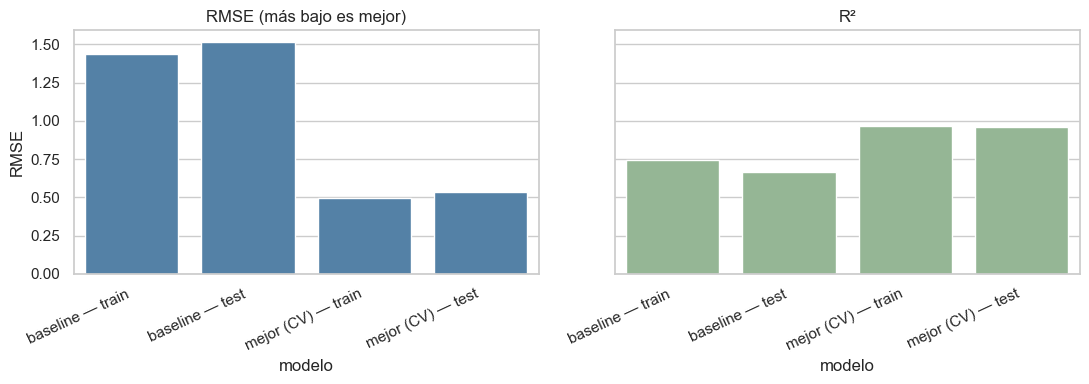

In [5]:
baseline = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=1, include_bias=False)),
        ("scale", StandardScaler()),
        ("linreg", LinearRegression()),
    ]
)
baseline.fit(X_train, y_train)

y_train_base = baseline.predict(X_train)
y_test_base = baseline.predict(X_test)

compare = pd.DataFrame(
    [
        report_metrics("baseline — train", y_train, y_train_base),
        report_metrics("baseline — test", y_test, y_test_base),
        report_metrics("mejor (CV) — train", y_train, y_train_hat),
        report_metrics("mejor (CV) — test", y_test, y_test_hat),
    ]
)
display(compare)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
x_order = ["baseline — train", "baseline — test", "mejor (CV) — train", "mejor (CV) — test"]
plot_df = compare.set_index("modelo").loc[x_order].reset_index()
sns.barplot(data=plot_df, x="modelo", y="RMSE", ax=axes[0], color="steelblue")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha="right")
axes[0].set_title("RMSE (más bajo es mejor)")
sns.barplot(data=plot_df, x="modelo", y="R2", ax=axes[1], color="darkseagreen")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha="right")
axes[1].set_title("R²")
plt.tight_layout()
plt.show()

### Curva ajustada vs datos (train y test)

Puntos: datos reales. Líneas: predicción del modelo sobre una malla ordenada en $x$ (baseline recta vs modelo elegido por CV).

In [ ]:
x_min = float(df["x"].min())
x_max = float(df["x"].max())
x_grid = np.linspace(x_min, x_max, 200).reshape(-1, 1)
X_line = pd.DataFrame(x_grid, columns=["x"])

y_line_best = best_model.predict(X_line)
y_line_base = baseline.predict(X_line)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train["x"], y_train, alpha=0.45, label="Train", s=28)
ax.scatter(X_test["x"], y_test, alpha=0.65, label="Test", s=32, marker="s")
ax.plot(X_line["x"], y_line_base, color="tab:gray", linewidth=2, label="Baseline (grado 1)")
ax.plot(X_line["x"], y_line_best, color="tab:red", linewidth=2, label="Mejor (CV)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Datos y curvas ajustadas")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

---
## 6. Validación de supuestos (modelo final sobre train)

Trabajamos con un modelo **lineal en las features** $(x, x^2, \ldots)$. Los supuestos clásicos se revisan sobre los **residuos** $\hat\varepsilon = y - \hat{y}$ en entrenamiento:

1. **Linealidad en las features:** si faltara estructura, en residuos vs valores ajustados aparecería un **patrón curvo** claro.
2. **Homocedasticidad:** varianza del error similar a lo largo de $\hat{y}$; si el gráfico abre en **abanico**, la varianza no es constante.
3. **Normalidad aproximada de residuos:** útil sobre todo si se hacen intervalos de confianza; un **Q-Q plot** comparando cuantiles empíricos con los de una normal detecta colas pesadas o asimetría.
4. **Independencia:** aquí las filas se generan de forma **independiente**; en datos con orden temporal o agrupación habría que discutir correlación serial u otros efectos.

*Nota:* entre potencias de $x$ hay **multicolinealidad** fuerte; Ridge y el escalado mitigan problemas numéricos, pero no sustituyen un buen diseño experimental.

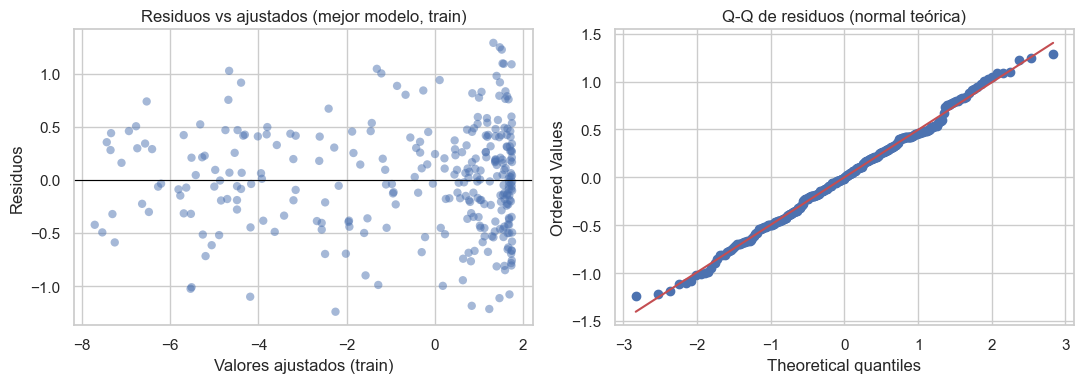

In [6]:
residuals_train = y_train.values - y_train_hat

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_train_hat, residuals_train, alpha=0.5, edgecolor="none")
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_xlabel("Valores ajustados (train)")
axes[0].set_ylabel("Residuos")
axes[0].set_title("Residuos vs ajustados (mejor modelo, train)")

stats.probplot(residuals_train, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q de residuos (normal teórica)")
plt.tight_layout()
plt.show()

---
## 7. Cierre

- El **test** se reservó para una lectura final; la **CV en train** eligió grado y `alpha`.
- Con datos simulados cuadráticos, suele verse que un grado $\geq 2$ mejora al baseline lineal, mientras Ridge evita que grados altos **exploten** varianza.
- Siguiente paso sugerido en el curso: repetir el flujo con un dataset **OpenML** y comparar supuestos y métricas cuando la relación ya no sea un polinomio perfecto.